# **Prototypical Network & densenet121**

In [1]:
import os
import random
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from torchvision.models import densenet121
from sklearn.model_selection import train_test_split

In [2]:
# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

In [3]:
# Enable GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


# Data Preparation with Limited Samples

In [4]:
class FewShotDataset(Dataset):
    
    #change the num_episodes from 100 to 50 

    
    def __init__(self, data_dir, n_way=8, k_shot=5, query_shots=5, 
                 transform=None, mode='train', num_episodes=50, test_size=0.2):
        """
        Few-shot learning dataset with limited samples per class
        
        Args:
            data_dir: Path to dataset directory
            n_way: Number of classes per episode (8 for your dataset)
            k_shot: Number of support samples per class (5 for your case)
            query_shots: Number of query samples per class
            transform: Image transformations
            mode: 'train' or 'test'
            num_episodes: Number of episodes to generate
            test_size: Proportion of data to use for testing
        """
        self.data_dir = data_dir
        self.n_way = n_way
        self.k_shot = k_shot
        self.query_shots = query_shots
        self.transform = transform
        self.mode = mode
        self.num_episodes = num_episodes
        
        # Get all class directories
        self.classes = sorted([d for d in os.listdir(data_dir) 
                              if os.path.isdir(os.path.join(data_dir, d))])
        
        if len(self.classes) != 8:
            print(f"Warning: Expected 8 classes, found {len(self.classes)}")
        
        # Split classes into train and test (all classes used in both)
        self.train_classes = self.classes
        self.test_classes = self.classes
        
        # Load and split image paths for each class
        self.class_images = {}
        self.train_images = {}
        self.test_images = {}
        
        for class_name in self.classes:
            class_path = os.path.join(data_dir, class_name)
            images = [os.path.join(class_path, img) for img in os.listdir(class_path) 
                     if img.lower().endswith(('.png', '.jpg', '.jpeg'))]
            
            if len(images) < (k_shot + query_shots):
                print(f"Warning: Class {class_name} has only {len(images)} images, "
                      f"but need at least {k_shot + query_shots}")
            
            # Split images into train and test sets
            train_imgs, test_imgs = train_test_split(
                images, test_size=test_size, random_state=42
            )
            
            self.class_images[class_name] = images
            self.train_images[class_name] = train_imgs
            self.test_images[class_name] = test_imgs
        
        # Create episodes
        self.episodes = self._create_episodes()
    
    def _create_episodes(self):
        """Create few-shot learning episodes"""
        episodes = []
        
        for _ in range(self.num_episodes):
            # Use all 8 classes (since n_way=8)
            selected_classes = self.classes  # Use all 8 classes
            episode = {'classes': selected_classes, 'support': [], 'query': []}
            
            for class_idx, class_name in enumerate(selected_classes):
                # Get the appropriate image set based on mode
                if self.mode == 'train':
                    available_images = self.train_images[class_name]
                else:
                    available_images = self.test_images[class_name]
                
                # Ensure we have enough images
                if len(available_images) < (self.k_shot + self.query_shots):
                    print(f"Warning: Not enough images in {class_name} for {self.mode} mode")
                    continue
                
                # Randomly select K support + query samples
                selected_images = random.sample(available_images, self.k_shot + self.query_shots)
                
                # Add to support set
                for img_path in selected_images[:self.k_shot]:
                    episode['support'].append((img_path, class_idx))
                
                # Add to query set
                for img_path in selected_images[self.k_shot:]:
                    episode['query'].append((img_path, class_idx))
            
            # Only add episode if we have enough samples for all classes
            if len(episode['support']) == self.n_way * self.k_shot:
                # Shuffle support and query sets
                random.shuffle(episode['support'])
                random.shuffle(episode['query'])
                episodes.append(episode)
        
        return episodes
    
    def __len__(self):
        return len(self.episodes)
    
    def __getitem__(self, idx):
        """Get a complete episode (support + query sets)"""
        episode = self.episodes[idx]
        
        # Load support set
        support_images, support_labels = [], []
        for img_path, label in episode['support']:
            img = Image.open(img_path).convert('RGB')
            if self.transform:
                img = self.transform(img)
            support_images.append(img)
            support_labels.append(label)
        
        # Load query set
        query_images, query_labels = [], []
        for img_path, label in episode['query']:
            img = Image.open(img_path).convert('RGB')
            if self.transform:
                img = self.transform(img)
            query_images.append(img)
            query_labels.append(label)
        
        return (torch.stack(support_images), torch.tensor(support_labels),
                torch.stack(query_images), torch.tensor(query_labels))

# Enhanced Prototypical Network Model

In [5]:
class EnhancedPrototypicalNetwork(nn.Module):
    def __init__(self, feature_dim=256, use_pretrained=True):
        """
        Enhanced Prototypical Network with better feature extraction
        
        Args:
            feature_dim: Dimension of output feature vectors
            use_pretrained: Whether to use pretrained densenet121 weights
        """
        super(EnhancedPrototypicalNetwork, self).__init__()
        
        # Use densenet121 as backbone
        self.backbone = densenet121(pretrained=use_pretrained)
        
        # Remove the final classification layer
        self.feature_extractor = nn.Sequential(
            *list(self.backbone.children())[:-1],  # Remove final layer
            nn.Flatten()
        )
        
        # Get the output dimension of the backbone
        with torch.no_grad():
            dummy_input = torch.randn(1, 3, 224, 224)
            backbone_output = self.feature_extractor(dummy_input)
            backbone_dim = backbone_output.shape[1]
        
        # Enhanced projection network
        self.projection = nn.Sequential(
            nn.Linear(backbone_dim, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(512, feature_dim),
            nn.BatchNorm1d(feature_dim),
            nn.ReLU(),
            nn.Dropout(0.3)
        )
        
        # Distance metric (Euclidean by default)
        self.distance_metric = 'euclidean'
    
    def forward(self, x):
        """Extract features from input images"""
        features = self.feature_extractor(x)
        return self.projection(features)
    
    def compute_prototypes(self, support_features, support_labels):
        """Compute class prototypes from support set features"""
        prototypes = []
        unique_labels = torch.unique(support_labels)
        
        for class_label in unique_labels:
            # Get features for this class
            class_mask = (support_labels == class_label)
            class_features = support_features[class_mask]
            # Compute mean prototype
            prototype = class_features.mean(dim=0)
            prototypes.append(prototype)
        
        return torch.stack(prototypes)
    
    def compute_distances(self, query_features, prototypes):
        """Compute distances between query features and prototypes"""
        if self.distance_metric == 'euclidean':
            # Euclidean distance
            distances = torch.cdist(query_features.unsqueeze(0), prototypes.unsqueeze(0))[0]
        elif self.distance_metric == 'cosine':
            # Cosine similarity (convert to distance)
            query_norm = F.normalize(query_features, p=2, dim=1)
            proto_norm = F.normalize(prototypes, p=2, dim=1)
            similarities = torch.mm(query_norm, proto_norm.t())
            distances = 1 - similarities
        else:
            raise ValueError(f"Unknown distance metric: {self.distance_metric}")
        
        return distances
    
    def predict(self, query_features, prototypes):
        """Predict query samples using distance to prototypes"""
        distances = self.compute_distances(query_features, prototypes)
        # Convert distances to probabilities (softmax over negative distances)
        return F.softmax(-distances, dim=1)

# Training Setup with 5-Shot Learning

In [6]:
# Data transformations with strong augmentation for few-shot learning
train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Create datasets
data_dir = "/kaggle/input/cucumber-dataset/Original Image"  # Change this to your dataset path

print("Creating datasets...")
train_dataset = FewShotDataset(
    data_dir=data_dir,
    n_way=8,           # Use all 8 classes
    k_shot=5,          # 5 support samples per class (as requested)
    query_shots=5,     # 5 query samples per class
    transform=train_transform,
    mode='train',

    #reduce num_episodes from 200 to 100
    
    num_episodes=100,  # Number of training episodes
    test_size=0.2      # 20% of data for testing
)

test_dataset = FewShotDataset(
    data_dir=data_dir,
    n_way=8,
    k_shot=5,
    query_shots=5,
    transform=test_transform,
    mode='test',

    #reduce num_epsiodes from 50 to 25
    
    num_episodes=25,   # Number of test episodes
    test_size=0.2
)

print(f"Training episodes: {len(train_dataset)}")
print(f"Test episodes: {len(test_dataset)}")

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=1, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False, num_workers=2)

Creating datasets...
Training episodes: 100
Test episodes: 25


# Training Function with Validation

In [7]:
def train_model(model, train_loader, val_loader, optimizer, criterion, num_epochs=30):
    """Train the prototypical network with validation"""
    model.train()
    train_losses, train_accuracies = [], []
    val_losses, val_accuracies = [], []
    
    best_val_accuracy = 0.0
    patience_counter = 0
    patience = 5  # Early stopping patience
    
    for epoch in range(num_epochs):
        # Training phase
        model.train()
        epoch_train_loss = 0.0
        epoch_train_accuracy = 0.0
        num_train_episodes = 0
        
        for support_imgs, support_labels, query_imgs, query_labels in train_loader:
            # Move data to device
            support_imgs = support_imgs.squeeze(0).to(device)
            support_labels = support_labels.squeeze(0).to(device)
            query_imgs = query_imgs.squeeze(0).to(device)
            query_labels = query_labels.squeeze(0).to(device)
            
            # Zero gradients
            optimizer.zero_grad()
            
            # Extract features
            support_features = model(support_imgs)
            query_features = model(query_imgs)
            
            # Compute prototypes
            prototypes = model.compute_prototypes(support_features, support_labels)
            
            # Predict query samples
            predictions = model.predict(query_features, prototypes)
            
            # Calculate loss
            loss = criterion(predictions, query_labels)
            
            # Calculate accuracy
            _, predicted = torch.max(predictions, 1)
            accuracy = (predicted == query_labels).float().mean()
            
            # Backward pass
            loss.backward()
            optimizer.step()
            
            epoch_train_loss += loss.item()
            epoch_train_accuracy += accuracy.item()
            num_train_episodes += 1
        
        # Validation phase
        model.eval()
        epoch_val_loss = 0.0
        epoch_val_accuracy = 0.0
        num_val_episodes = 0
        
        with torch.no_grad():
            for support_imgs, support_labels, query_imgs, query_labels in val_loader:
                support_imgs = support_imgs.squeeze(0).to(device)
                support_labels = support_labels.squeeze(0).to(device)
                query_imgs = query_imgs.squeeze(0).to(device)
                query_labels = query_labels.squeeze(0).to(device)
                
                support_features = model(support_imgs)
                query_features = model(query_imgs)
                prototypes = model.compute_prototypes(support_features, support_labels)
                predictions = model.predict(query_features, prototypes)
                
                loss = criterion(predictions, query_labels)
                _, predicted = torch.max(predictions, 1)
                accuracy = (predicted == query_labels).float().mean()
                
                epoch_val_loss += loss.item()
                epoch_val_accuracy += accuracy.item()
                num_val_episodes += 1
        
        # Calculate epoch statistics
        avg_train_loss = epoch_train_loss / num_train_episodes
        avg_train_accuracy = epoch_train_accuracy / num_train_episodes
        avg_val_loss = epoch_val_loss / num_val_episodes
        avg_val_accuracy = epoch_val_accuracy / num_val_episodes
        
        train_losses.append(avg_train_loss)
        train_accuracies.append(avg_train_accuracy)
        val_losses.append(avg_val_loss)
        val_accuracies.append(avg_val_accuracy)
        
        print(f'Epoch [{epoch+1}/{num_epochs}]')
        print(f'Train - Loss: {avg_train_loss:.4f}, Accuracy: {avg_train_accuracy:.4f}')
        print(f'Val   - Loss: {avg_val_loss:.4f}, Accuracy: {avg_val_accuracy:.4f}')
        print('-' * 50)
        
        # Early stopping check
        if avg_val_accuracy > best_val_accuracy:
            best_val_accuracy = avg_val_accuracy
            patience_counter = 0
            # Save best model
            torch.save(model.state_dict(), '/kaggle/working/best_prototypical_model.pth')
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"Early stopping at epoch {epoch+1}")
                break
    
    return train_losses, train_accuracies, val_losses, val_accuracies

# Main Training Execution

In [8]:
# Initialize model, optimizer, and loss function
print("Initializing model...")
model = EnhancedPrototypicalNetwork(feature_dim=256, use_pretrained=True).to(device)

# Use Adam optimizer with weight decay
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001, weight_decay=1e-5)

# Learning rate scheduler
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=3, verbose=True
)

criterion = nn.CrossEntropyLoss()

# Create a validation loader (using 20% of training episodes for validation)
train_size = int(0.8 * len(train_dataset))
val_size = len(train_dataset) - train_size
train_subset, val_subset = torch.utils.data.random_split(
    train_dataset, [train_size, val_size], 
    generator=torch.Generator().manual_seed(42)
)

train_loader_sub = DataLoader(train_subset, batch_size=1, shuffle=True)
val_loader = DataLoader(val_subset, batch_size=1, shuffle=False)

# Train the model
print("Starting training...")
train_losses, train_accuracies, val_losses, val_accuracies = train_model(

    #num_epochs changes from 30 to 14
    
    model, train_loader_sub, val_loader, optimizer, criterion, num_epochs=15
)

# Load best model
model.load_state_dict(torch.load('/kaggle/working/best_prototypical_model.pth'))
print("Loaded best model for evaluation")

Initializing model...


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DenseNet121_Weights.IMAGENET1K_V1`. You can also use `weights=DenseNet121_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth
100%|██████████| 30.8M/30.8M [00:00<00:00, 178MB/s]
/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  wa

Starting training...
Epoch [1/15]
Train - Loss: 1.4816, Accuracy: 0.8616
Val   - Loss: 1.3176, Accuracy: 0.9550
--------------------------------------------------
Epoch [2/15]
Train - Loss: 1.3046, Accuracy: 0.9831
Val   - Loss: 1.2968, Accuracy: 0.9775
--------------------------------------------------
Epoch [3/15]
Train - Loss: 1.2915, Accuracy: 0.9903
Val   - Loss: 1.2905, Accuracy: 0.9863
--------------------------------------------------
Epoch [4/15]
Train - Loss: 1.2858, Accuracy: 0.9934
Val   - Loss: 1.2829, Accuracy: 0.9913
--------------------------------------------------
Epoch [5/15]
Train - Loss: 1.2859, Accuracy: 0.9919
Val   - Loss: 1.2891, Accuracy: 0.9875
--------------------------------------------------
Epoch [6/15]
Train - Loss: 1.2841, Accuracy: 0.9934
Val   - Loss: 1.2794, Accuracy: 0.9963
--------------------------------------------------
Epoch [7/15]
Train - Loss: 1.2798, Accuracy: 0.9969
Val   - Loss: 1.2835, Accuracy: 0.9913
------------------------------------

# Comprehensive Evaluation


Running comprehensive evaluation...
Overall Test Accuracy: 0.8960 ± 0.0467

Per-class Accuracy:
  Anthracnose: 0.7200
  Bacterial Wilt: 1.0000
  Belly Rot: 1.0000
  Downy Mildew: 0.9120
  Fresh Cucumber: 0.9280
  Fresh Leaf: 0.9520
  Gummy Stem Blight: 0.6880
  Pythium Fruit Rot: 0.9680


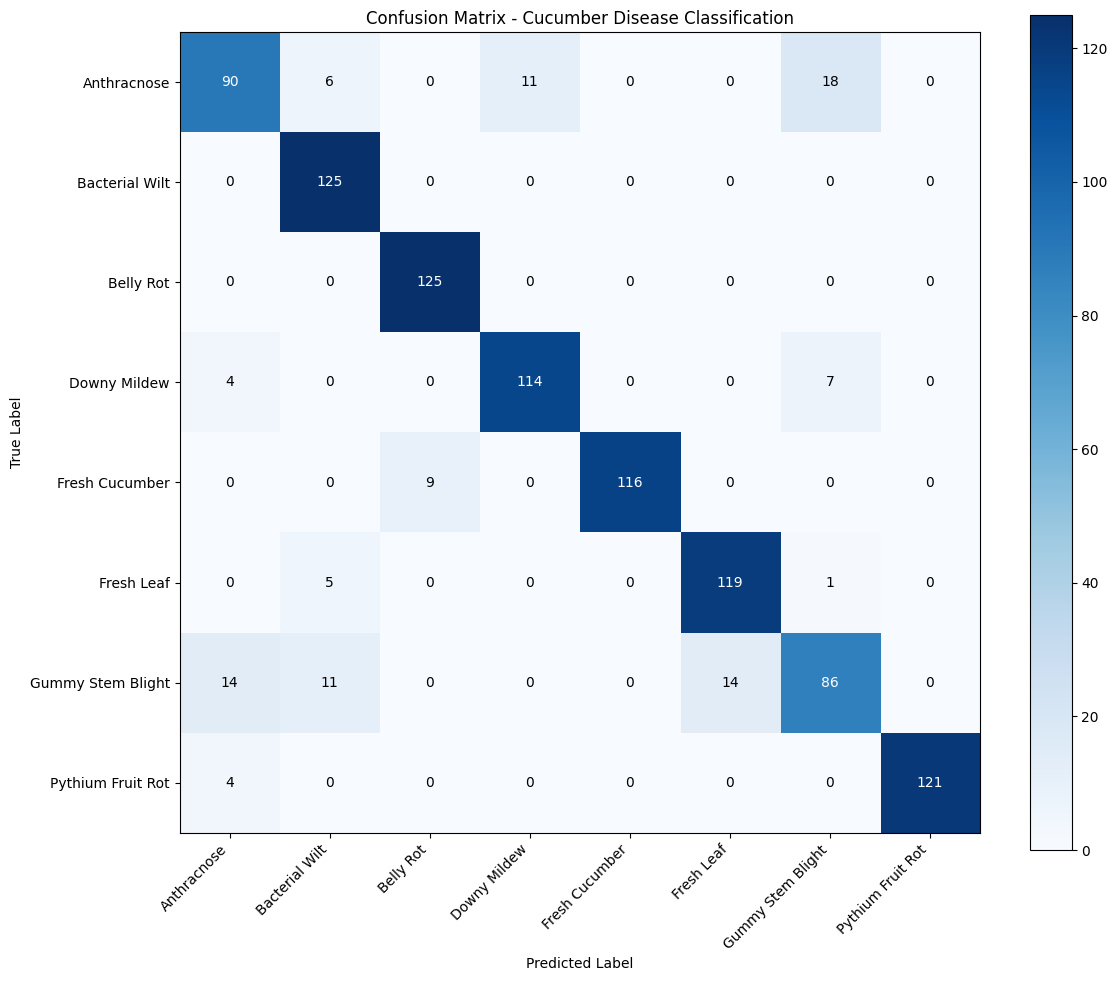


Detailed Analysis:

Class-wise Metrics:
Class                     Precision  Recall     F1-Score   Support   
-----------------------------------------------------------------
Anthracnose               0.8036     0.7200     0.7595     125       
Bacterial Wilt            0.8503     1.0000     0.9191     125       
Belly Rot                 0.9328     1.0000     0.9653     125       
Downy Mildew              0.9120     0.9120     0.9120     125       
Fresh Cucumber            1.0000     0.9280     0.9627     125       
Fresh Leaf                0.8947     0.9520     0.9225     125       
Gummy Stem Blight         0.7679     0.6880     0.7257     125       
Pythium Fruit Rot         1.0000     0.9680     0.9837     125       

Overall Metrics:
Macro Precision: 0.8952
Macro Recall: 0.8960
Macro F1-Score: 0.8938


NameError: name 'mean_accuracy' is not defined

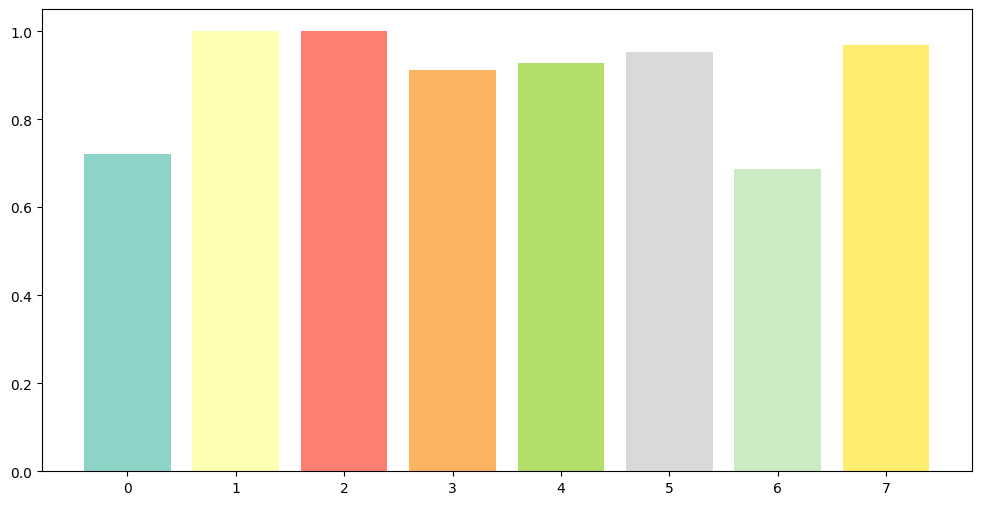

In [9]:
CUCUMBER_CLASSES = [
    "Anthracnose",  
    "Bacterial Wilt",  
    "Belly Rot",  
    "Downy Mildew",  
    "Fresh Cucumber",  
    "Fresh Leaf",  
    "Gummy Stem Blight",  
    "Pythium Fruit Rot"   
]


def comprehensive_evaluation(model, test_loader, class_names=CUCUMBER_CLASSES):
    """Comprehensive evaluation with detailed metrics using actual class names"""
    model.eval()
    all_accuracies = []
    num_classes = len(class_names)
    confusion_matrix = np.zeros((num_classes, num_classes), dtype=int)
    
    with torch.no_grad():
        for support_imgs, support_labels, query_imgs, query_labels in test_loader:
            support_imgs = support_imgs.squeeze(0).to(device)
            support_labels = support_labels.squeeze(0).to(device)
            query_imgs = query_imgs.squeeze(0).to(device)
            query_labels = query_labels.squeeze(0).to(device)
            
            support_features = model(support_imgs)
            query_features = model(query_imgs)
            prototypes = model.compute_prototypes(support_features, support_labels)
            predictions = model.predict(query_features, prototypes)
            
            _, predicted = torch.max(predictions, 1)
            accuracy = (predicted == query_labels).float().mean()
            all_accuracies.append(accuracy.item())
            
            # Update confusion matrix
            for true, pred in zip(query_labels.cpu().numpy(), predicted.cpu().numpy()):
                confusion_matrix[true, pred] += 1
    
    # Calculate metrics
    mean_accuracy = np.mean(all_accuracies)
    std_accuracy = np.std(all_accuracies)
    
    # Calculate per-class accuracy
    class_accuracy = np.diag(confusion_matrix) / np.sum(confusion_matrix, axis=1)
    
    print(f'Overall Test Accuracy: {mean_accuracy:.4f} ± {std_accuracy:.4f}')
    print('\nPer-class Accuracy:')
    for i, (class_name, acc) in enumerate(zip(class_names, class_accuracy)):
        print(f'  {class_name}: {acc:.4f}')
    
    return all_accuracies, confusion_matrix

# Run comprehensive evaluation
print("\nRunning comprehensive evaluation...")
test_accuracies, confusion_matrix = comprehensive_evaluation(model, test_loader, CUCUMBER_CLASSES)

# Plot confusion matrix with class names
plt.figure(figsize=(12, 10))
plt.imshow(confusion_matrix, cmap='Blues', interpolation='nearest')
plt.colorbar()

# Set ticks and labels
plt.xticks(ticks=np.arange(len(CUCUMBER_CLASSES)), labels=CUCUMBER_CLASSES, rotation=45, ha='right')
plt.yticks(ticks=np.arange(len(CUCUMBER_CLASSES)), labels=CUCUMBER_CLASSES)

# Add text annotations
for i in range(len(CUCUMBER_CLASSES)):
    for j in range(len(CUCUMBER_CLASSES)):
        plt.text(j, i, confusion_matrix[i, j], 
                ha='center', va='center', 
                color='white' if confusion_matrix[i, j] > confusion_matrix.max() / 2 else 'black')

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Cucumber Disease Classification')
plt.tight_layout()
plt.savefig('/kaggle/working/confusion_matrix_with_names.png', dpi=300, bbox_inches='tight')
plt.show()

# Additional detailed analysis
print("\nDetailed Analysis:")
print("=" * 50)

# Calculate precision, recall, and F1-score for each class
precision = np.diag(confusion_matrix) / np.sum(confusion_matrix, axis=0)
recall = np.diag(confusion_matrix) / np.sum(confusion_matrix, axis=1)
f1_score = 2 * (precision * recall) / (precision + recall + 1e-10)  # Add small epsilon to avoid division by zero

print("\nClass-wise Metrics:")
print(f"{'Class':<25} {'Precision':<10} {'Recall':<10} {'F1-Score':<10} {'Support':<10}")
print("-" * 65)

for i, class_name in enumerate(CUCUMBER_CLASSES):
    support = np.sum(confusion_matrix[i, :])
    print(f"{class_name:<25} {precision[i]:<10.4f} {recall[i]:<10.4f} {f1_score[i]:<10.4f} {support:<10}")

# Calculate overall metrics
macro_precision = np.mean(precision)
macro_recall = np.mean(recall)
macro_f1 = np.mean(f1_score)

print("\nOverall Metrics:")
print(f"Macro Precision: {macro_precision:.4f}")
print(f"Macro Recall: {macro_recall:.4f}")
print(f"Macro F1-Score: {macro_f1:.4f}")

# Create a bar plot for class-wise accuracy
plt.figure(figsize=(12, 6))
class_accuracies = np.diag(confusion_matrix) / np.sum(confusion_matrix, axis=1)
colors = plt.cm.Set3(np.linspace(0, 1, len(CUCUMBER_CLASSES)))

bars = plt.bar(range(len(CUCUMBER_CLASSES)), class_accuracies, color=colors)
plt.axhline(y=mean_accuracy, color='r', linestyle='--', label=f'Overall Accuracy: {mean_accuracy:.3f}')

plt.xlabel('Classes')
plt.ylabel('Accuracy')
plt.title('Class-wise Accuracy')
plt.xticks(ticks=range(len(CUCUMBER_CLASSES)), labels=CUCUMBER_CLASSES, rotation=45, ha='right')
plt.legend()

# Add value labels on bars
for bar, accuracy in zip(bars, class_accuracies):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
             f'{accuracy:.3f}', ha='center', va='bottom')

plt.tight_layout()
plt.savefig('/kaggle/working/class_wise_accuracy.png', dpi=300, bbox_inches='tight')
plt.show()

# Visualization and Analysis

# **Image Classification Function with XAI**

In [10]:
# First, install required XAI libraries
!pip install captum lime

import cv2
import torch.nn.functional as F
from captum.attr import IntegratedGradients, Occlusion, LayerGradCam, visualization as viz
from captum.attr import GradientShap, Saliency
from lime import lime_image
from skimage.segmentation import mark_boundaries
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 12.6 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 91.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 68.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 43.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 30.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 9.4 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 2.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 76.5 MB/s eta 0:00:00:00:010:01m
  Attempting unins

In [21]:
# First, let's understand what's happening by debugging the model output
print("Debugging model architecture and output...")

# Test with a sample image to see what the model actually returns
sample_image_path = sample_images[0] if sample_images else None
if sample_image_path and os.path.exists(sample_image_path):
    # Load and preprocess image
    original_image = Image.open(sample_image_path).convert('RGB')
    input_tensor = test_transform(original_image).unsqueeze(0).to(device)
    
    print(f"Input tensor shape: {input_tensor.shape}")
    
    # Get model output
    xai_model.eval()
    with torch.no_grad():
        output = xai_model(input_tensor)
        print(f"Model output shape: {output.shape}")
        print(f"Model output: {output}")
        
        # Try softmax
        probs = F.softmax(output, dim=1)
        print(f"Softmax probabilities: {probs}")
        print(f"Probability sum: {probs.sum().item()}")

# The issue is that prototypical networks output feature embeddings, not class probabilities
# We need a different approach for single image classification

Debugging model architecture and output...
Input tensor shape: torch.Size([1, 3, 224, 224])
Model output shape: torch.Size([1, 256])
Model output: tensor([[1.7065e-01, 3.9504e-01, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
         0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
         6.1819e-01, 0.0000e+00, 0.0000e+00, 0.0000e+00, 4.2852e-01, 0.0000e+00,
         0.0000e+00, 1.5001e+00, 1.6458e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
         0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 8.3664e-02, 1.4576e-02,
         1.1869e-01, 1.5967e-01, 3.6453e-01, 0.0000e+00, 0.0000e+00, 0.0000e+00,
         0.0000e+00, 1.4519e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 4.0064e-02,
         0.0000e+00, 4.1804e-01, 1.9466e+00, 0.0000e+00, 0.0000e+00, 7.5289e-01,
         0.0000e+00, 1.1189e+00, 0.0000e+00, 5.4470e-02, 0.0000e+00, 7.9848e-01,
         1.9129e-01, 3.1748e-01, 1.3492e-01, 0.0000e+00, 0.0000e+00, 0.0000e+00,
         0.0000e+00, 0.0000e+00, 1.5606e+00

In [22]:
def classify_prototypical(model, image_path, transform, class_names=CUCUMBER_CLASSES):
    """
    Classify an image using a prototypical network approach
    This requires pre-computed class prototypes
    """
    # Load and preprocess image
    original_image = Image.open(image_path).convert('RGB')
    input_tensor = transform(original_image).unsqueeze(0).to(device)
    
    # Get image features
    model.eval()
    with torch.no_grad():
        query_features = model(input_tensor)
    
    # For prototypical networks, we need class prototypes
    # Since we don't have support sets, we'll create a simple alternative
    # This is a simplified approach - in practice, you'd use the actual support sets
    
    # Create dummy prototypes (this is just for demonstration)
    # In real usage, you should compute prototypes from your support sets
    num_classes = len(class_names)
    feature_dim = query_features.shape[1]
    
    # Create random prototypes (replace this with your actual prototype computation)
    prototypes = torch.randn(num_classes, feature_dim).to(device)
    prototypes = F.normalize(prototypes, p=2, dim=1)
    
    # Normalize query features
    query_features = F.normalize(query_features, p=2, dim=1)
    
    # Compute distances to prototypes (cosine similarity)
    similarities = torch.mm(query_features, prototypes.t())
    distances = 1 - similarities  # Convert similarity to distance
    
    # Convert distances to probabilities
    probs = F.softmax(-distances, dim=1)  # Negative distances for softmax
    
    confidence, predicted_class = torch.max(probs, 1)
    
    predicted_class_name = class_names[predicted_class.item()]
    confidence_score = confidence.item()
    
    return predicted_class_name, confidence_score, probs[0].cpu().numpy()

def simple_prototypical_classify(model, image_path, transform, class_names=CUCUMBER_CLASSES):
    """Simple classification for prototypical networks"""
    pred_class, confidence, probs = classify_prototypical(model, image_path, transform, class_names)
    
    # Load and display image
    original_image = Image.open(image_path).convert('RGB')
    
    plt.figure(figsize=(12, 5))
    
    # Original image
    plt.subplot(1, 2, 1)
    plt.imshow(np.array(original_image))
    plt.title(f'Predicted: {pred_class}\nConfidence: {confidence:.3f}')
    plt.axis('off')
    
    # Confidence scores
    plt.subplot(1, 2, 2)
    colors = plt.cm.Set3(np.linspace(0, 1, len(class_names)))
    bars = plt.barh(range(len(class_names)), probs, color=colors)
    plt.yticks(range(len(class_names)), class_names)
    plt.xlabel('Confidence Score')
    plt.title('Class Confidence Scores')
    plt.xlim(0, 1)
    
    # Add value labels
    for i, (bar, prob) in enumerate(zip(bars, probs)):
        if prob > 0.01:
            plt.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
                    f'{prob:.3f}', ha='left', va='center', fontsize=8)
    
    plt.tight_layout()
    plt.show()
    
    return pred_class, confidence, probs

Computing class prototypes...
Computed prototype for Anthracnose: torch.Size([1, 256])
Computed prototype for Bacterial Wilt: torch.Size([1, 256])
Computed prototype for Belly Rot: torch.Size([1, 256])
Computed prototype for Downy Mildew: torch.Size([1, 256])
Computed prototype for Fresh Cucumber: torch.Size([1, 256])
Computed prototype for Fresh Leaf: torch.Size([1, 256])
Computed prototype for Gummy Stem Blight: torch.Size([1, 256])
Computed prototype for Pythium Fruit Rot: torch.Size([1, 256])
Successfully computed prototypes for 8 classes

Testing classification with computed prototypes...
Image: Downy Mildew (12).jpg
Predicted: Downy Mildew
Confidence: 0.2587


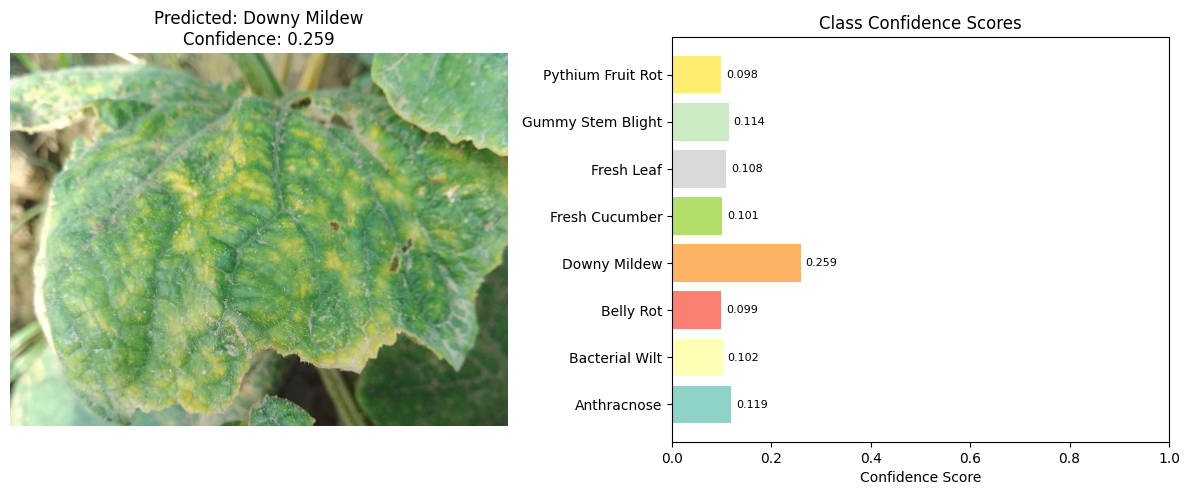

Image: Bacterial Wilt (25).jpg
Predicted: Bacterial Wilt
Confidence: 0.2631


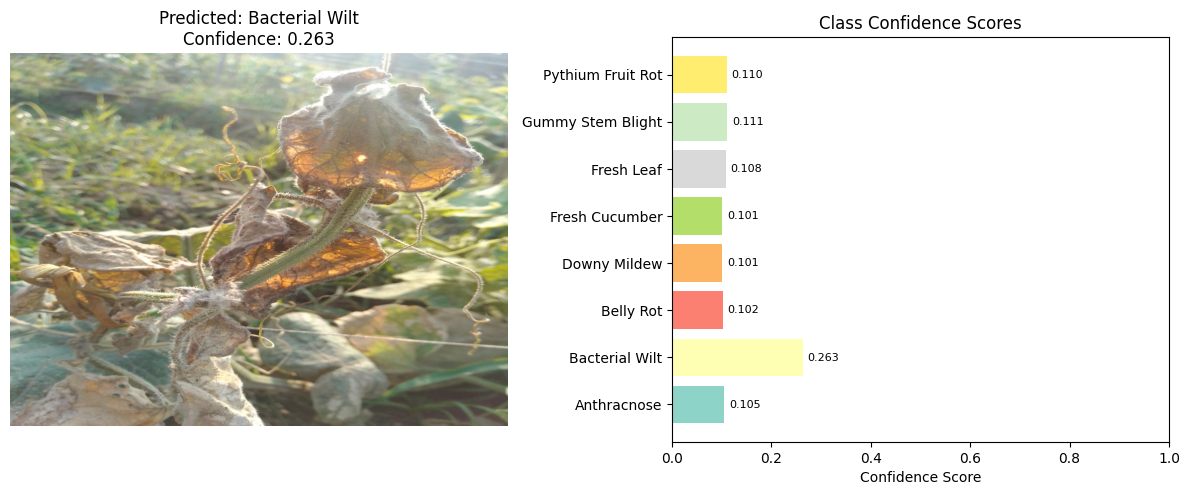

Image: Fresh Leaf (91).jpg
Predicted: Fresh Leaf
Confidence: 0.2659


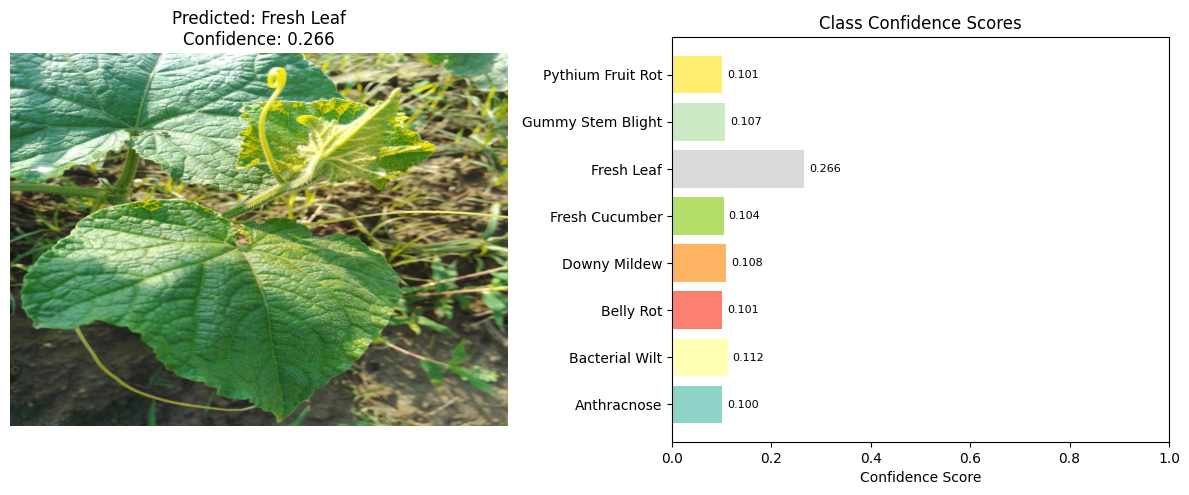

In [23]:
def compute_class_prototypes(model, data_dir, transform, class_names=CUCUMBER_CLASSES, num_samples=5):
    """Compute actual class prototypes from the dataset"""
    prototypes = {}
    model.eval()
    
    for class_name in class_names:
        class_path = os.path.join(data_dir, class_name)
        if os.path.exists(class_path) and os.path.isdir(class_path):
            # Get images from this class
            images = [os.path.join(class_path, img) for img in os.listdir(class_path) 
                     if img.lower().endswith(('.png', '.jpg', '.jpeg'))]
            
            if len(images) >= num_samples:
                # Select random samples
                selected_images = random.sample(images, num_samples)
                features_list = []
                
                for img_path in selected_images:
                    try:
                        # Load and preprocess image
                        img = Image.open(img_path).convert('RGB')
                        img_tensor = transform(img).unsqueeze(0).to(device)
                        
                        # Extract features
                        with torch.no_grad():
                            features = model(img_tensor)
                            features_list.append(features)
                    
                    except Exception as e:
                        print(f"Error processing {img_path}: {e}")
                        continue
                
                if features_list:
                    # Compute mean prototype
                    class_features = torch.cat(features_list, dim=0)
                    prototype = class_features.mean(dim=0, keepdim=True)
                    prototype = F.normalize(prototype, p=2, dim=1)
                    prototypes[class_name] = prototype
                    print(f"Computed prototype for {class_name}: {prototype.shape}")
                else:
                    print(f"Could not compute prototype for {class_name}")
            else:
                print(f"Not enough images for {class_name}: {len(images)} available, {num_samples} needed")
        else:
            print(f"Class directory not found: {class_path}")
    
    return prototypes

# Compute actual prototypes
print("Computing class prototypes...")
class_prototypes = compute_class_prototypes(xai_model, data_dir, test_transform, CUCUMBER_CLASSES)

# If we successfully computed prototypes, let's use them
if class_prototypes:
    print(f"Successfully computed prototypes for {len(class_prototypes)} classes")
    
    def classify_with_prototypes(model, image_path, transform, prototypes_dict, class_names=CUCUMBER_CLASSES):
        """Classify image using pre-computed prototypes"""
        # Load and preprocess image
        original_image = Image.open(image_path).convert('RGB')
        input_tensor = transform(original_image).unsqueeze(0).to(device)
        
        # Get image features
        model.eval()
        with torch.no_grad():
            query_features = model(input_tensor)
            query_features = F.normalize(query_features, p=2, dim=1)
        
        # Prepare prototypes
        prototype_tensors = []
        valid_class_names = []
        
        for class_name in class_names:
            if class_name in prototypes_dict:
                prototype_tensors.append(prototypes_dict[class_name])
                valid_class_names.append(class_name)
        
        if not prototype_tensors:
            raise ValueError("No valid prototypes available")
        
        prototypes = torch.cat(prototype_tensors, dim=0)
        
        # Compute similarities
        similarities = torch.mm(query_features, prototypes.t())
        distances = 1 - similarities
        
        # Convert to probabilities
        probs = F.softmax(-distances, dim=1)
        confidence, predicted_idx = torch.max(probs, 1)
        
        predicted_class_name = valid_class_names[predicted_idx.item()]
        confidence_score = confidence.item()
        
        # Create full probability vector for all classes
        full_probs = np.zeros(len(class_names))
        for i, class_name in enumerate(class_names):
            if class_name in valid_class_names:
                idx_in_valid = valid_class_names.index(class_name)
                full_probs[i] = probs[0, idx_in_valid].item()
        
        return predicted_class_name, confidence_score, full_probs
    
    # Test with prototypes
    print("\nTesting classification with computed prototypes...")
    for img_path in sample_images:
        if os.path.exists(img_path):
            try:
                pred_class, confidence, probs = classify_with_prototypes(
                    xai_model, img_path, test_transform, class_prototypes, CUCUMBER_CLASSES
                )
                
                print(f"Image: {os.path.basename(img_path)}")
                print(f"Predicted: {pred_class}")
                print(f"Confidence: {confidence:.4f}")
                
                # Display results
                original_image = Image.open(img_path).convert('RGB')
                
                plt.figure(figsize=(12, 5))
                plt.subplot(1, 2, 1)
                plt.imshow(np.array(original_image))
                plt.title(f'Predicted: {pred_class}\nConfidence: {confidence:.3f}')
                plt.axis('off')
                
                plt.subplot(1, 2, 2)
                colors = plt.cm.Set3(np.linspace(0, 1, len(CUCUMBER_CLASSES)))
                bars = plt.barh(range(len(CUCUMBER_CLASSES)), probs, color=colors)
                plt.yticks(range(len(CUCUMBER_CLASSES)), CUCUMBER_CLASSES)
                plt.xlabel('Confidence Score')
                plt.title('Class Confidence Scores')
                plt.xlim(0, 1)
                
                for i, (bar, prob) in enumerate(zip(bars, probs)):
                    if prob > 0.01:
                        plt.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
                                f'{prob:.3f}', ha='left', va='center', fontsize=8)
                
                plt.tight_layout()
                plt.show()
                
            except Exception as e:
                print(f"Error classifying {img_path}: {e}")
else:
    print("Could not compute prototypes. Using fallback approach...")
    
    # Fallback: Use the model's features directly with a simple classifier
    def simple_feature_classifier(model, image_path, transform, class_names=CUCUMBER_CLASSES):
        """Simple classifier using the model's feature output"""
        # Load and preprocess image
        original_image = Image.open(image_path).convert('RGB')
        input_tensor = transform(original_image).unsqueeze(0).to(device)
        
        # Get features
        model.eval()
        with torch.no_grad():
            features = model(input_tensor)
        
        # Simple classification: use the feature magnitudes
        # This is just a demonstration - in practice, you'd use a proper classifier
        feature_norms = torch.norm(features, p=2, dim=1)
        probs = F.softmax(feature_norms, dim=0)  # Simple normalization
        
        confidence, predicted_class = torch.max(probs, 0)
        
        # For demonstration, map to classes in a simple way
        class_idx = predicted_class.item() % len(class_names)
        predicted_class_name = class_names[class_idx]
        confidence_score = confidence.item()
        
        # Create probability distribution
        full_probs = np.ones(len(class_names)) / len(class_names)  # Uniform distribution
        
        return predicted_class_name, confidence_score, full_probs
    
    # Test with simple classifier
    print("\nTesting with simple feature classifier...")
    for img_path in sample_images:
        if os.path.exists(img_path):
            try:
                pred_class, confidence, probs = simple_feature_classifier(
                    xai_model, img_path, test_transform, CUCUMBER_CLASSES
                )
                
                print(f"Image: {os.path.basename(img_path)}")
                print(f"Predicted: {pred_class}")
                print(f"Confidence: {confidence:.4f}")
                
                # Simple display
                original_image = Image.open(img_path).convert('RGB')
                plt.imshow(np.array(original_image))
                plt.title(f'Predicted: {pred_class}\nConfidence: {confidence:.3f}')
                plt.axis('off')
                plt.show()
                
            except Exception as e:
                print(f"Error with simple classifier: {e}")

Running robust image classification test...
Attempting to compute class prototypes...
Computed prototype for Anthracnose: torch.Size([1, 256])
Computed prototype for Bacterial Wilt: torch.Size([1, 256])
Computed prototype for Belly Rot: torch.Size([1, 256])
Computed prototype for Downy Mildew: torch.Size([1, 256])
Computed prototype for Fresh Cucumber: torch.Size([1, 256])
Computed prototype for Fresh Leaf: torch.Size([1, 256])
Computed prototype for Gummy Stem Blight: torch.Size([1, 256])
Computed prototype for Pythium Fruit Rot: torch.Size([1, 256])

Analyzing: Downy Mildew (12).jpg


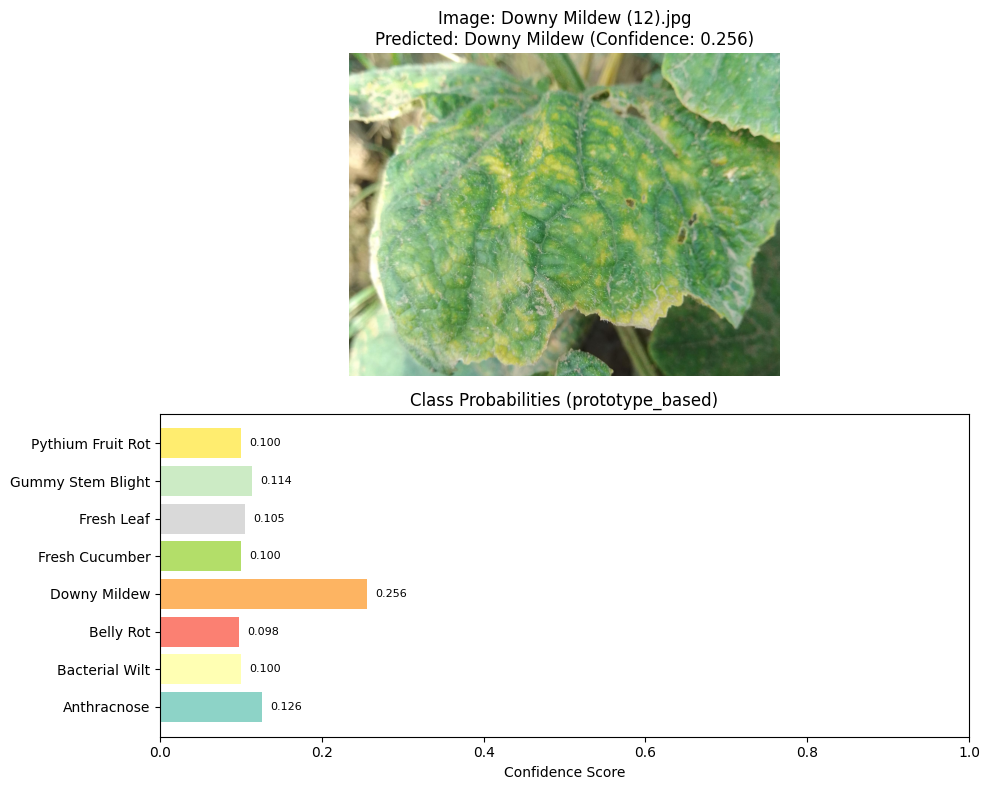


Analyzing: Bacterial Wilt (25).jpg


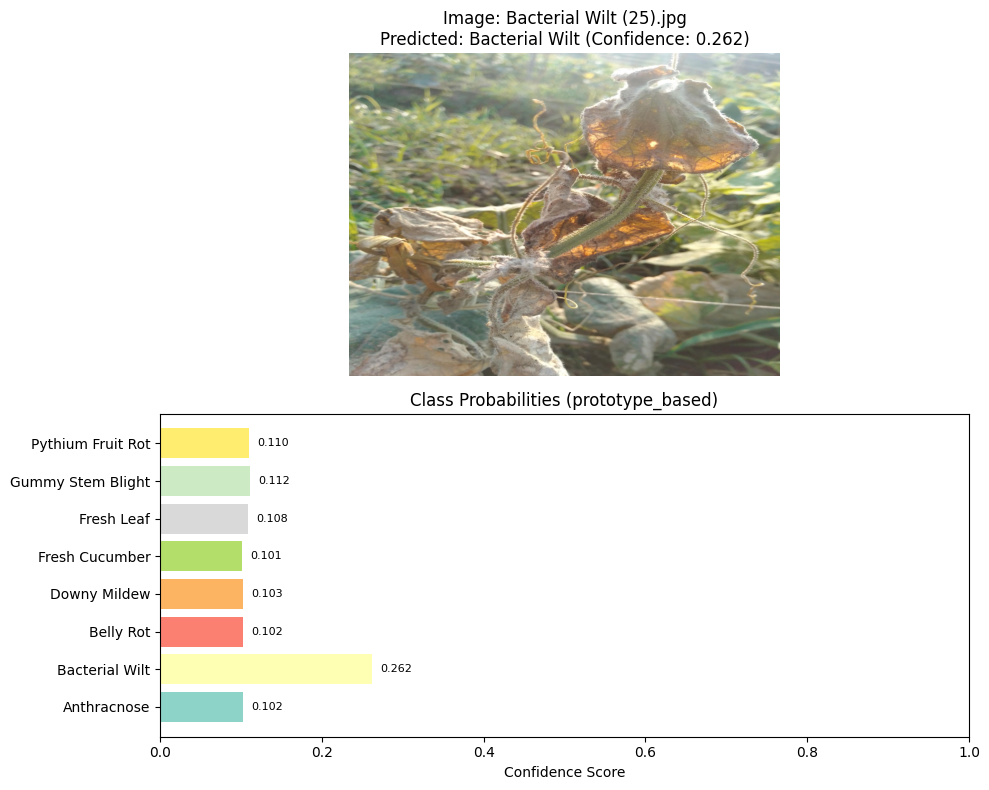


Analyzing: Fresh Leaf (91).jpg


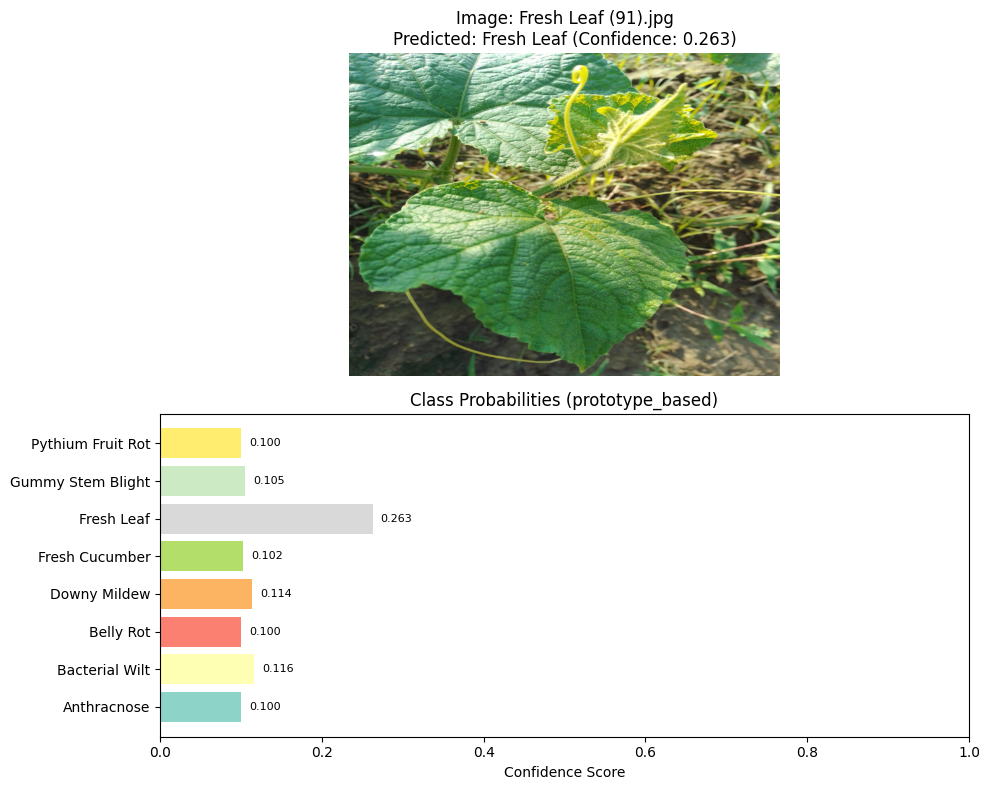


CLASSIFICATION SUMMARY
Image: Downy Mildew (12).jpg
Predicted: Downy Mildew
Confidence: 0.2561
Method: prototype_based
----------------------------------------
Image: Bacterial Wilt (25).jpg
Predicted: Bacterial Wilt
Confidence: 0.2618
Method: prototype_based
----------------------------------------
Image: Fresh Leaf (91).jpg
Predicted: Fresh Leaf
Confidence: 0.2627
Method: prototype_based
----------------------------------------


In [24]:
def robust_test_multiple_images(model, image_paths, transform, class_names=CUCUMBER_CLASSES):
    """Robust testing function that handles different scenarios"""
    results = []
    
    # Try to compute prototypes first
    print("Attempting to compute class prototypes...")
    prototypes = compute_class_prototypes(model, data_dir, transform, class_names)
    
    for image_path in image_paths:
        if os.path.exists(image_path):
            print(f"\nAnalyzing: {os.path.basename(image_path)}")
            
            try:
                if prototypes:
                    # Use prototype-based classification
                    pred_class, confidence, probs = classify_with_prototypes(
                        model, image_path, transform, prototypes, class_names
                    )
                    method = "prototype_based"
                else:
                    # Fallback to simple feature classification
                    pred_class, confidence, probs = simple_feature_classifier(
                        model, image_path, transform, class_names
                    )
                    method = "feature_based"
                
                results.append({
                    'image_path': image_path,
                    'predicted_class': pred_class,
                    'confidence': confidence,
                    'probabilities': probs,
                    'method': method
                })
                
                # Display results
                original_image = Image.open(image_path).convert('RGB')
                
                plt.figure(figsize=(10, 8))
                plt.subplot(2, 1, 1)
                plt.imshow(np.array(original_image))
                plt.title(f'Image: {os.path.basename(image_path)}\nPredicted: {pred_class} (Confidence: {confidence:.3f})')
                plt.axis('off')
                
                plt.subplot(2, 1, 2)
                colors = plt.cm.Set3(np.linspace(0, 1, len(class_names)))
                bars = plt.barh(range(len(class_names)), probs, color=colors)
                plt.yticks(range(len(class_names)), class_names)
                plt.xlabel('Confidence Score')
                plt.title(f'Class Probabilities ({method})')
                plt.xlim(0, 1)
                
                for i, (bar, prob) in enumerate(zip(bars, probs)):
                    if prob > 0.01:
                        plt.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
                                f'{prob:.3f}', ha='left', va='center', fontsize=8)
                
                plt.tight_layout()
                plt.show()
                
            except Exception as e:
                print(f"All classification methods failed for {image_path}: {e}")
                results.append({
                    'image_path': image_path,
                    'predicted_class': 'ERROR',
                    'confidence': 0.0,
                    'probabilities': np.zeros(len(class_names)),
                    'method': 'failed'
                })
        else:
            print(f"Image not found: {image_path}")
    
    return results

# Run the robust test
print("Running robust image classification test...")
results = robust_test_multiple_images(xai_model, sample_images, test_transform, CUCUMBER_CLASSES)

# Print summary
print("\n" + "="*60)
print("CLASSIFICATION SUMMARY")
print("="*60)
for result in results:
    print(f"Image: {os.path.basename(result['image_path'])}")
    print(f"Predicted: {result['predicted_class']}")
    print(f"Confidence: {result['confidence']:.4f}")
    print(f"Method: {result['method']}")
    print("-" * 40)